# Aula 2: Algoritmo de Grover 

In [1]:
from qiskit_aer import AerSimulator
from qiskit.circuit.library import RealAmplitudes
from qiskit.circuit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import *

In [2]:
from qiskit.providers.fake_provider import *

In [3]:
from qiskit_ibm_runtime.fake_provider import *

In [4]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit, transpile, assemble
from qiskit.visualization import plot_histogram

In [5]:
from qiskit.circuit.library import MCMT

In [6]:
from qiskit_aer import Aer

# Portas multicontroladas

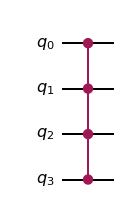

In [7]:
n=4
c4z = MCMT('cz',n-1,1)
c4z.draw('mpl')

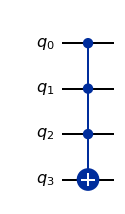

In [8]:
n=4
c4x = MCMT('cx',n-1,1)
c4x.draw('mpl')

In [9]:
import math
import time
import numpy as np

## Circuito

In [10]:
def fidelity(p,q):
    if len(p) != len(q):
        raise ValueError("inputs with different length")
    return sum([math.sqrt(i[0]*i[1]) for i in zip(p,q)])

def fidelity2(p,q):
    if len(p) != len(q):
        
        raise ValueError("inputs with different length")
    return sum([abs(i[0]-i[1]) for i in zip(p,q)])/2.

Algoritmo de Grover

Seja $f:\{0,1, \ldots , N-1\} \rightarrow \{0,1\}$. Supomos que apenas um ı́ndice, chamado de $\omega$, satisfaz
$f(x) = 1$, e nosso objetivo é identificar esse ı́ndice.
  
\begin{cases}
U_{\omega} |x\rangle = -|x\rangle \quad \text{para, } x=\omega\, f(x)=1, \\
U_{\omega} |x\rangle = \,\,\,\, |x\rangle \quad \text{para, } x\neq \omega\, f(x)=0.
\end{cases}

Pode ser expresso como:
\begin{equation}
U_{\omega} |x\rangle = (-1)^{f(x)}|x\rangle .
\end{equation}

Em forma matricial:
\begin{equation}
U_{\omega} = I -2| \omega \rangle \langle \omega | .
\end{equation}

O operador difusor $(U_s)$:
\begin{equation}
U_s = 2|s \rangle \langle s| - I.
\end{equation}

O operador de evolução de Grover, $U_G$, é dado por:
\begin{equation}
U_G = U_s \, U_{\omega}.
\end{equation}

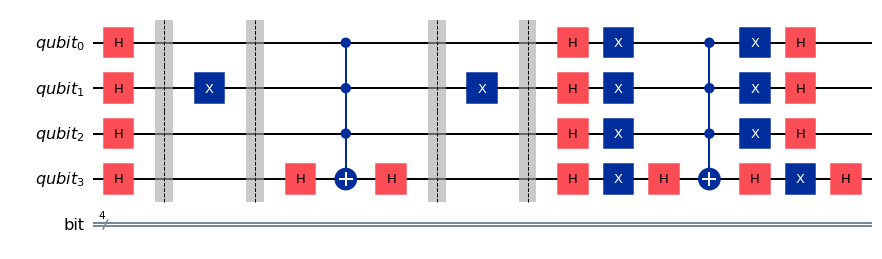

In [11]:
from qiskit import QuantumCircuit
 
n = 4
q = QuantumRegister(n, 'qubit')
c = ClassicalRegister(n, 'bit')
qc = QuantumCircuit(q, c)
 
# Add a Hadamard gate to qubit 0
#qc.x(3)

qc.h(range(n))

#################################################################
qc.barrier(range(n))
#oracle
#qc.x(0)
qc.x(1)
#qc.x(2)
qc.barrier(0,1,2,3)
#qc.h(3)
#qc.ccx(0,1,2)
qc.h(3)
qc.compose(c4x,qubits=[0,1,2,3],inplace=True)
#qc.append(X,control(3),[0,1,2,3])
qc.h(3)
qc.barrier(range(n))
#qc.x(0)
qc.x(1)
#qc.x(2)
#qc.barrier(0,1,2,3)
#qc.x(0)
#qc.barrier(0,1,2,3)
#qc.h(3)
#qc.compose(c4x,qubits=[0,1,2,3],inplace=True)
#qc.h(3)
#qc.barrier(0,1,2,3)
#qc.ccx(0,1,2)
#qc.h(2)
#qc.x(0)

#################################################################
qc.barrier(range(n))
# difussion
qc.h(range(n))
qc.x(range(n))

#qc.h(2)
#qc.ccz(0,1,2)
#qc.h(2)
qc.h(3)
qc.compose(c4x,qubits=[0,1,2,3],inplace=True)
qc.h(3)

qc.x(range(n))
qc.h(range(n))

qc.draw('mpl')

In [12]:
from qiskit.quantum_info import Statevector

In [13]:
psi = Statevector(qc)
psi.draw(output = "latex")

<IPython.core.display.Latex object>

In [14]:
def counting_to_probability(contagem):
    m = sum(list(contagem.values()))
    n = len(list(contagem.keys())[0])
    L = [bin(i)[2:] for i in range(2**n)]
    L = list(map(lambda x: '0'*(n-len(x))+x,L))
    return {j:contagem[j]/m for j in contagem.keys()}

### Simulador 

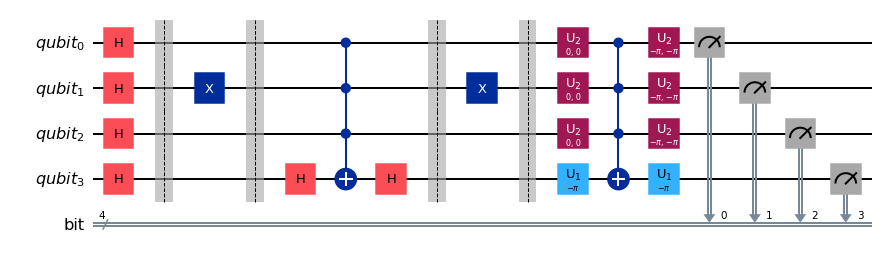

In [15]:
from qiskit_aer.aerprovider import AerSimulator
qc.measure(q,c)

simulator = AerSimulator()
circ = transpile(qc, simulator)

circ.draw('mpl')

In [16]:
result = simulator.run(circ,shots=2000).result()
counts = result.get_counts(qc)

In [20]:
probs = counting_to_probability(counts)
sorted_probs = dict(sorted(probs.items()))
print(sorted_probs)
#probs

{'0000': 0.0355, '0001': 0.0365, '0010': 0.025, '0011': 0.0385, '0100': 0.0365, '0101': 0.0275, '0110': 0.0395, '0111': 0.043, '1000': 0.038, '1001': 0.03, '1010': 0.0365, '1011': 0.0325, '1100': 0.033, '1101': 0.486, '1110': 0.029, '1111': 0.033}


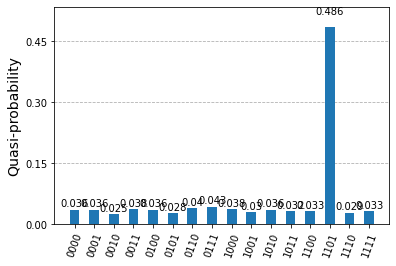

In [21]:
plot_histogram(probs)

# Fake Providers 

In [22]:
backend2= FakeLagosV2() #7Q
result2= backend2.run(qc,shots = 4000).result()
counts2 = result2.get_counts(qc)  

In [23]:
probs2 = counting_to_probability(counts2)
sorted_probs2 = dict(sorted(probs2.items()))
print(sorted_probs2)

{'0000': 0.02075, '0001': 0.02625, '0010': 0.024, '0011': 0.029, '0100': 0.045, '0101': 0.05375, '0110': 0.04675, '0111': 0.04425, '1000': 0.049, '1001': 0.11575, '1010': 0.027, '1011': 0.02975, '1100': 0.0945, '1101': 0.266, '1110': 0.0435, '1111': 0.08475}


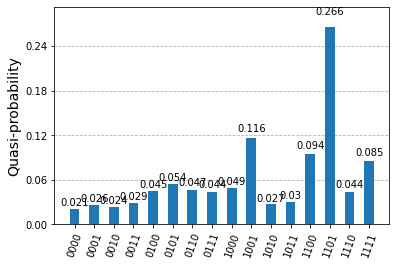

In [24]:
plot_histogram(probs2)

In [25]:
backend3= FakeAuckland() #27Q
result3= backend3.run(qc,shots = 4000).result()
counts3 = result3.get_counts(qc)  

In [26]:
probs3 = counting_to_probability(counts3)
sorted_probs3 = dict(sorted(probs3.items()))
print(sorted_probs3)

{'0000': 0.034, '0001': 0.0345, '0010': 0.03375, '0011': 0.03075, '0100': 0.0335, '0101': 0.041, '0110': 0.038, '0111': 0.036, '1000': 0.032, '1001': 0.0355, '1010': 0.0325, '1011': 0.0405, '1100': 0.04075, '1101': 0.46425, '1110': 0.0335, '1111': 0.0395}


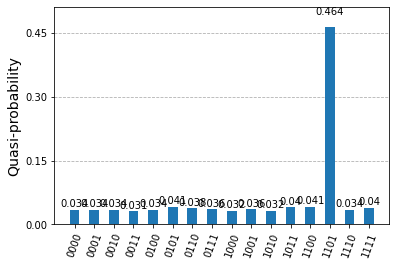

In [27]:
plot_histogram(probs3)

In [28]:
backend4= FakeOsaka() #127Q
result4= backend4.run(qc,shots = 4000).result()
counts4 = result4.get_counts(qc)  

In [30]:
probs4 = counting_to_probability(counts4)
sorted_probs4 = dict(sorted(probs4.items()))
print(sorted_probs4)

{'0000': 0.03725, '0001': 0.037, '0010': 0.03, '0011': 0.03425, '0100': 0.029, '0101': 0.046, '0110': 0.03275, '0111': 0.03275, '1000': 0.03425, '1001': 0.0495, '1010': 0.0355, '1011': 0.0445, '1100': 0.048, '1101': 0.4355, '1110': 0.038, '1111': 0.03575}


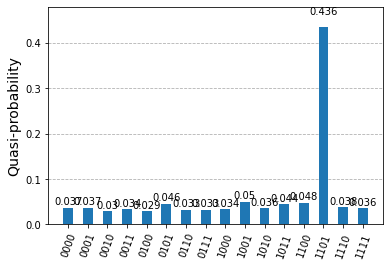

In [31]:
plot_histogram(probs4)

## 2 elementos marcados

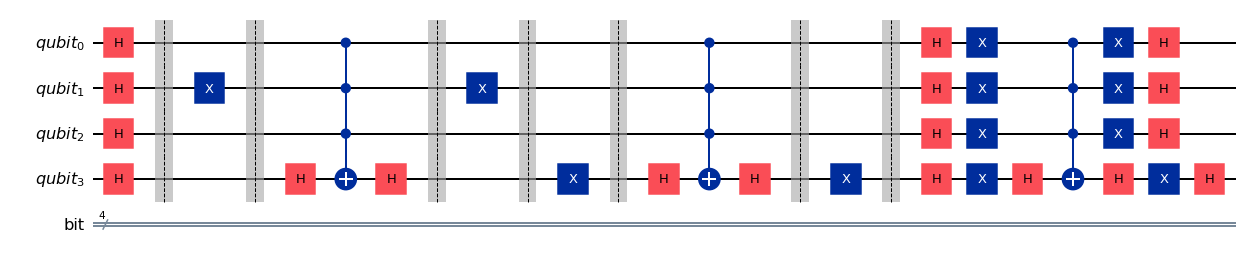

In [32]:
n = 4
q = QuantumRegister(n, 'qubit')
c = ClassicalRegister(n, 'bit')
qc1 = QuantumCircuit(q, c)
 
# Add a Hadamard gate to qubit 0
#qc.x(3)

qc1.h(range(n))

#################################################################
qc1.barrier(range(n))
#oracle
#qc.x(0)
qc1.x(1)
#qc.x(2)
qc1.barrier(0,1,2,3)
#qc.h(3)
qc1.h(3)
qc1.compose(c4x,qubits=[0,1,2,3],inplace=True)
#qc.append(X,control(3),[0,1,2,3])
qc1.h(3)
qc1.barrier(range(n))
#qc.x(0)
qc1.x(1)
qc1.barrier(range(n))
qc1.x(3)
qc1.barrier(range(n))
qc1.h(3)
qc1.compose(c4x,qubits=[0,1,2,3],inplace=True)
qc1.h(3)
qc1.barrier(range(n))
qc1.x(3)

#################################################################
qc1.barrier(range(n))
# difussion
qc1.h(range(n))
qc1.x(range(n))

qc1.h(3)
qc1.compose(c4x,qubits=[0,1,2,3],inplace=True)
qc1.h(3)

qc1.x(range(n))
qc1.h(range(n))

qc1.draw('mpl')

In [33]:
psi = Statevector(qc1)
psi.draw(output = "latex")

<IPython.core.display.Latex object>

In [34]:
from qiskit_aer.aerprovider import AerSimulator
qc1.measure(q,c)
simulator = AerSimulator()
circ2 = transpile(qc1, simulator)

# Run and get counts
result21 = simulator.run(circ2,shots=2000).result()
counts21 = result21.get_counts(circ2)

In [35]:
probs21 = counting_to_probability(counts21)
sorted_probs21 = dict(sorted(probs21.items()))
print(sorted_probs21)

{'0000': 0.0155, '0001': 0.018, '0010': 0.014, '0011': 0.018, '0100': 0.0165, '0101': 0.02, '0110': 0.0125, '0111': 0.3875, '1000': 0.0155, '1001': 0.016, '1010': 0.0135, '1011': 0.0115, '1100': 0.022, '1101': 0.389, '1110': 0.0145, '1111': 0.016}


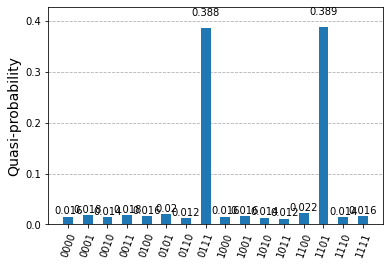

In [36]:
plot_histogram(probs21)

In [37]:
backend21= FakeLagosV2() #7Q
result22= backend21.run(qc1,shots = 4000).result()
counts22 = result22.get_counts(qc1)  

In [38]:
probs22 = counting_to_probability(counts22)
sorted_probs21 = dict(sorted(probs22.items()))
print(sorted_probs21)

{'0000': 0.0115, '0001': 0.02225, '0010': 0.0275, '0011': 0.08775, '0100': 0.02675, '0101': 0.0625, '0110': 0.05525, '0111': 0.2035, '1000': 0.0255, '1001': 0.09325, '1010': 0.016, '1011': 0.02325, '1100': 0.05725, '1101': 0.2065, '1110': 0.028, '1111': 0.05325}


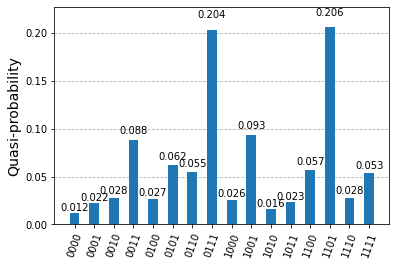

In [39]:
plot_histogram(probs22)

In [40]:
backend31= FakeAuckland() #27Q
result31= backend31.run(qc1,shots = 4000).result()
counts31= result31.get_counts(qc1) 

In [41]:
probs32 = counting_to_probability(counts31)
sorted_probs32 = dict(sorted(probs32.items()))
print(sorted_probs32)

{'0000': 0.018, '0001': 0.01825, '0010': 0.015, '0011': 0.017, '0100': 0.012, '0101': 0.02675, '0110': 0.01875, '0111': 0.378, '1000': 0.018, '1001': 0.01875, '1010': 0.01475, '1011': 0.014, '1100': 0.0205, '1101': 0.376, '1110': 0.01575, '1111': 0.0185}


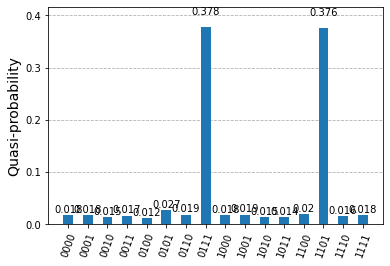

In [42]:
plot_histogram(probs32)

In [43]:
backend41= FakeOsaka() #127Q
result41= backend41.run(qc1,shots = 4000).result()
counts41 = result41.get_counts(qc1)  

In [44]:
probs42 = counting_to_probability(counts41)
sorted_probs42 = dict(sorted(probs42.items()))
print(sorted_probs42)

{'0000': 0.018, '0001': 0.018, '0010': 0.01525, '0011': 0.021, '0100': 0.01675, '0101': 0.0325, '0110': 0.0215, '0111': 0.3375, '1000': 0.01575, '1001': 0.026, '1010': 0.02, '1011': 0.015, '1100': 0.026, '1101': 0.3695, '1110': 0.01825, '1111': 0.029}


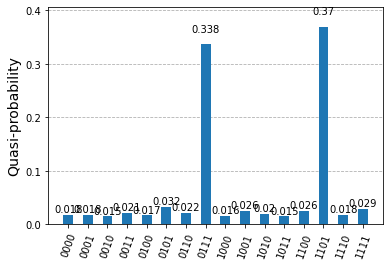

In [45]:
plot_histogram(probs42)